
# Inspección y Visualización de Datos con Pandas y Matplotlib

Este notebook muestra un ejemplo práctico de cómo inspeccionar datos, visualizar distribuciones,
analizar relaciones entre variables e identificar outliers usando **pandas** y **matplotlib**.


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuración para gráficos más nítidos
plt.rcParams["figure.figsize"] = (8, 5)
plt.style.use("ggplot")



## 1. Creación de un dataset de ejemplo


In [ ]:

np.random.seed(42)
datos = pd.DataFrame({
    "Edad": np.random.randint(18, 70, 100),
    "Ingresos": np.random.normal(3000, 800, 100),
    "Gasto_Salud": np.random.normal(500, 200, 100)
})

# Introducimos algunos outliers artificiales
datos.loc[5, "Ingresos"] = 15000
datos.loc[10, "Gasto_Salud"] = 2500



## 2. Inspección de datos


In [ ]:

print("\n--- Primeras filas ---")
print(datos.head())

print("\n--- Información general ---")
print(datos.info())

print("\n--- Estadísticas descriptivas ---")
print(datos.describe())



--- Primeras filas ---
   Edad     Ingresos  Gasto_Salud
0    56  1499.458582   294.457827
1    69  1906.574289   648.248127
2    46  3509.044087   157.894084
3    32  2274.623465   523.795698
4    60  3380.834070   700.097122

--- Información general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Edad         100 non-null    int64  
 1   Ingresos     100 non-null    float64
 2   Gasto_Salud  100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

--- Estadísticas descriptivas ---
             Edad      Ingresos  Gasto_Salud
count  100.000000    100.000000   100.000000
mean    43.350000   3140.730435   508.359556
std     14.904663   1445.031706   285.202444
min     19.000000   1448.071025    36.386350
25%     31.750000   2379.633865   353.368787
50%     42.000000   2949.391356   484.516181
75%     57.000000   3599.


## 3. Visualización univariada

Histogramas y boxplots para observar la distribución y detectar posibles outliers.


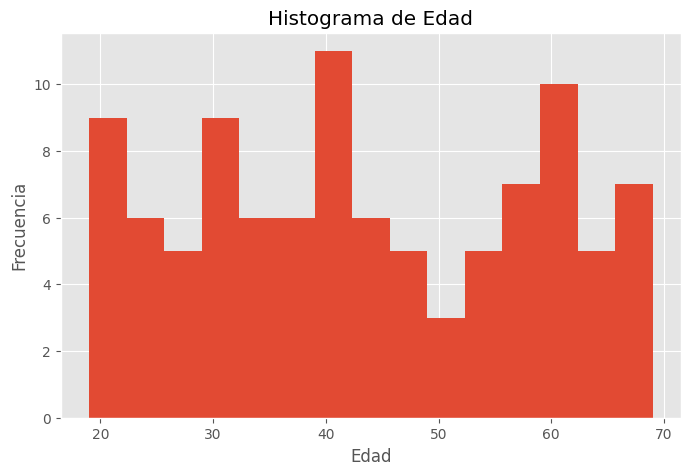

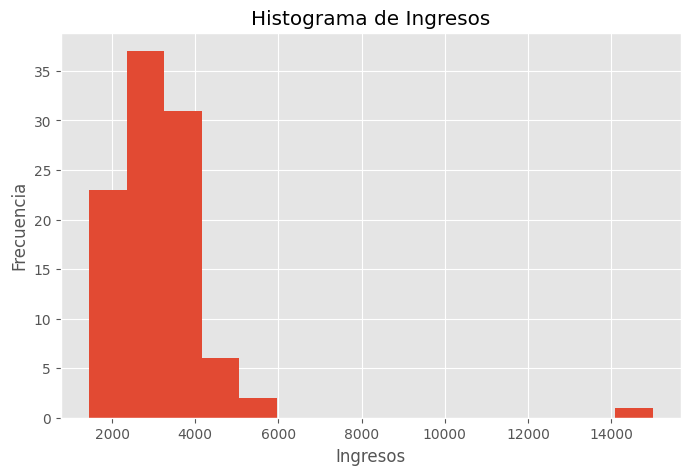

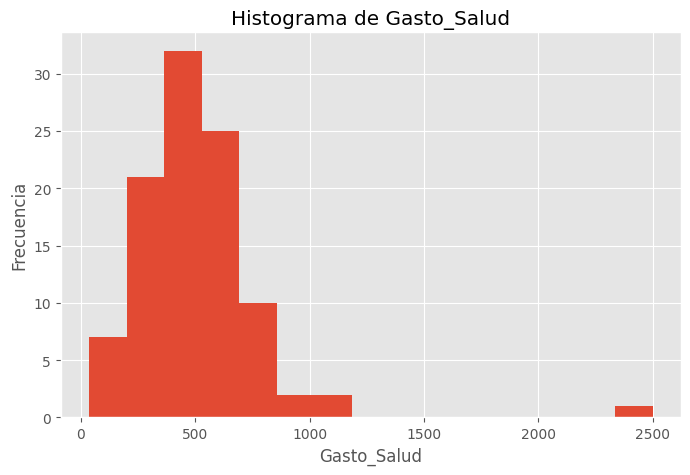

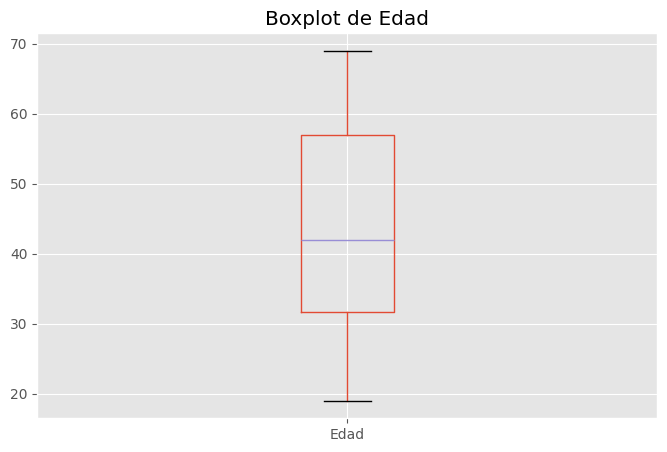

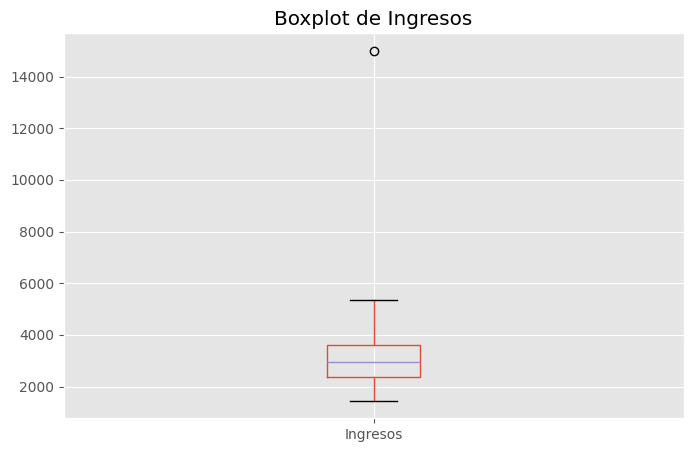

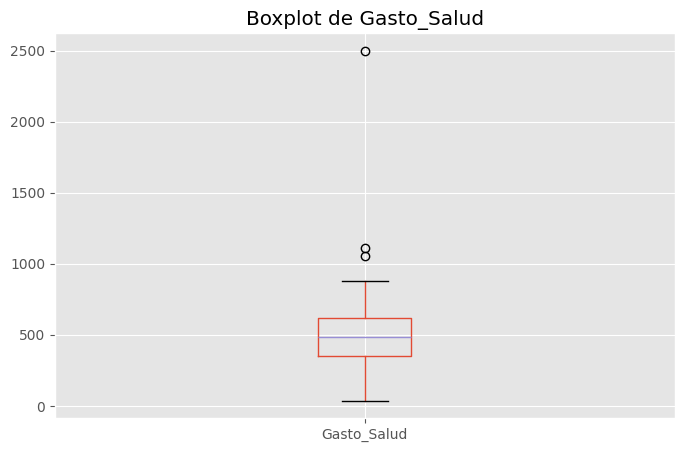

In [ ]:

# Histogramas
for columna in datos.columns:
    datos[columna].hist(bins=15)
    plt.title(f"Histograma de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Frecuencia")
    plt.show()

# Boxplots
for columna in datos.columns:
    datos.boxplot(column=columna)
    plt.title(f"Boxplot de {columna}")
    plt.show()



## 4. Relaciones entre variables



--- Correlaciones ---
                 Edad  Ingresos  Gasto_Salud
Edad         1.000000 -0.120718    -0.003380
Ingresos    -0.120718  1.000000     0.076491
Gasto_Salud -0.003380  0.076491     1.000000


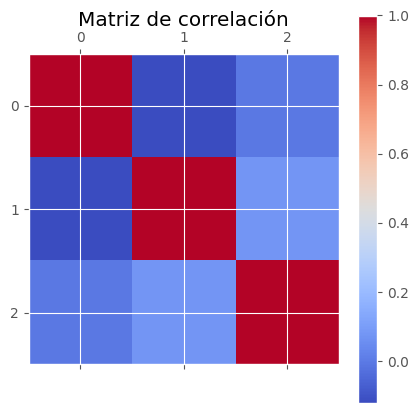

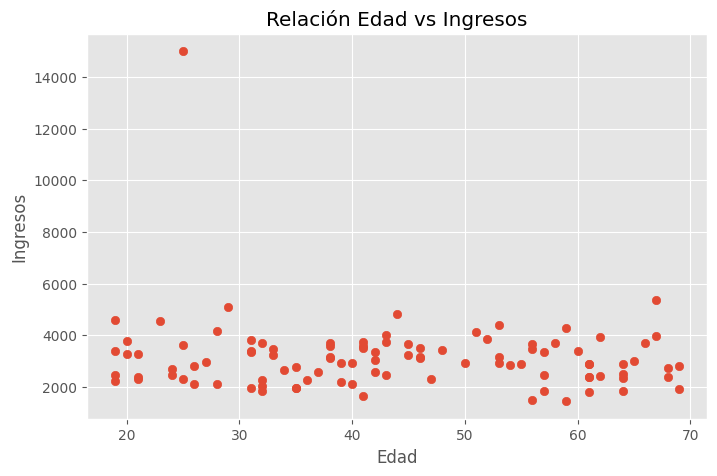

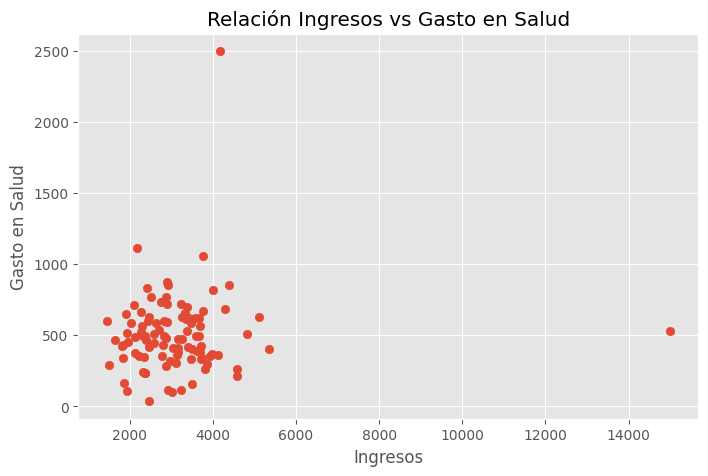

In [ ]:

# Matriz de correlación
print("\n--- Correlaciones ---")
print(datos.corr())

plt.matshow(datos.corr(), cmap="coolwarm")
plt.colorbar()
plt.title("Matriz de correlación", pad=20)
plt.show()

# Scatterplots
plt.scatter(datos["Edad"], datos["Ingresos"])
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.title("Relación Edad vs Ingresos")
plt.show()

plt.scatter(datos["Ingresos"], datos["Gasto_Salud"])
plt.xlabel("Ingresos")
plt.ylabel("Gasto en Salud")
plt.title("Relación Ingresos vs Gasto en Salud")
plt.show()



## 5. Identificación de outliers con regla IQR


In [ ]:

Q1 = datos["Ingresos"].quantile(0.25)
Q3 = datos["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

outliers = datos[(datos["Ingresos"] < Q1 - 1.5*IQR) | (datos["Ingresos"] > Q3 + 1.5*IQR)]

#Conceptos previos

#Q1 (primer cuartil): el valor debajo del cual se encuentra el 25% de los datos.

#Q3 (tercer cuartil): el valor debajo del cual se encuentra el 75% de los datos.

#IQR (InterQuartile Range o rango intercuartílico): diferencia entre Q3 y Q1.


#datos["Ingresos"] < Q1 - 1.5*IQR
#Encuentra valores muy bajos, por debajo del límite inferior permitido.

#datos["Ingresos"] > Q3 + 1.5*IQR
#Encuentra valores muy altos, por encima del límite superior permitido.

#El operador | significa "o" lógico, es decir, selecciona los casos donde se cumple alguna de las dos condicione#

print("\n--- Posibles outliers en Ingresos ---")
print(outliers)



--- Posibles outliers en Ingresos ---
   Edad  Ingresos  Gasto_Salud
5    25   15000.0   530.484172


In [ ]:
Q1 = datos["Gasto_Salud"].quantile(0.25)
Q3 = datos["Gasto_Salud"].quantile(0.75)
IQR = Q3 - Q1

outliers = datos[(datos["Gasto_Salud"] < Q1 - 1.5*IQR) | (datos["Gasto_Salud"] > Q3 + 1.5*IQR)]

print("\n--- Posibles outliers en Ingresos ---")
print(outliers)


--- Posibles outliers en Ingresos ---
    Edad     Ingresos  Gasto_Salud
10    28  4175.153028  2500.000000
27    39  2179.927289  1112.219043
40    20  3770.113032  1056.787609


In [ ]:
print (datos)

    Edad     Ingresos  Gasto_Salud
0     56  1499.458582   294.457827
1     69  1906.574289   648.248127
2     46  3509.044087   157.894084
3     32  2274.623465   523.795698
4     60  3380.834070   700.097122
..   ...          ...          ...
95    42  3052.519326   413.211680
96    62  3935.366118   353.461560
97    58  3698.653575   384.344617
98    46  3164.520107   472.856524
99    32  1845.213319   341.298996

[100 rows x 3 columns]
